[DEBUG 21:05:57] Configuration Dashboard Loaded.
[DEBUG 21:05:57] Generating synthetic catalog with physical distributions...
[DEBUG 21:05:57] Starting Ultra-High Res Grid Search Inference...
[DEBUG 21:07:41] Likelihood evaluation for 50000 points finished in 103.58 s

════════════════════════════════════════════════════════════════════════
 ASTROPHYSICAL GW LEAKAGE TEST REPORT (ULTRA RES) 
════════════════════════════════════════════════════════════════════════
Target Leakage (Eta)           : 0.020000
Recovered MAP (Peak)           : 0.012466
68% Confidence Interval        : [0.011918, 0.013008]
Significance (Sigma)           : 22.76 σ
Savage-Dickey Bayes Factor     : 2.349e+110
════════════════════════════════════════════════════════════════════════


/tmp/ipykernel_13292/4134497986.py:222: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  post_density = post_unnorm / np.trapz(post_unnorm, x=eta_grid)
/tmp/ipykernel_13292/4134497986.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  post /= np.trapz(post, x=eta_grid) if hasattr(np, 'trapz') else np.trapezoid(post, x=eta_grid)
/tmp/ipykernel_13292/4134497986.py:159: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_pos = float(np.trapz(post[eta_grid > 0], x=eta_grid[eta_grid > 0])) if np.any(eta_grid > 0) else float("nan")


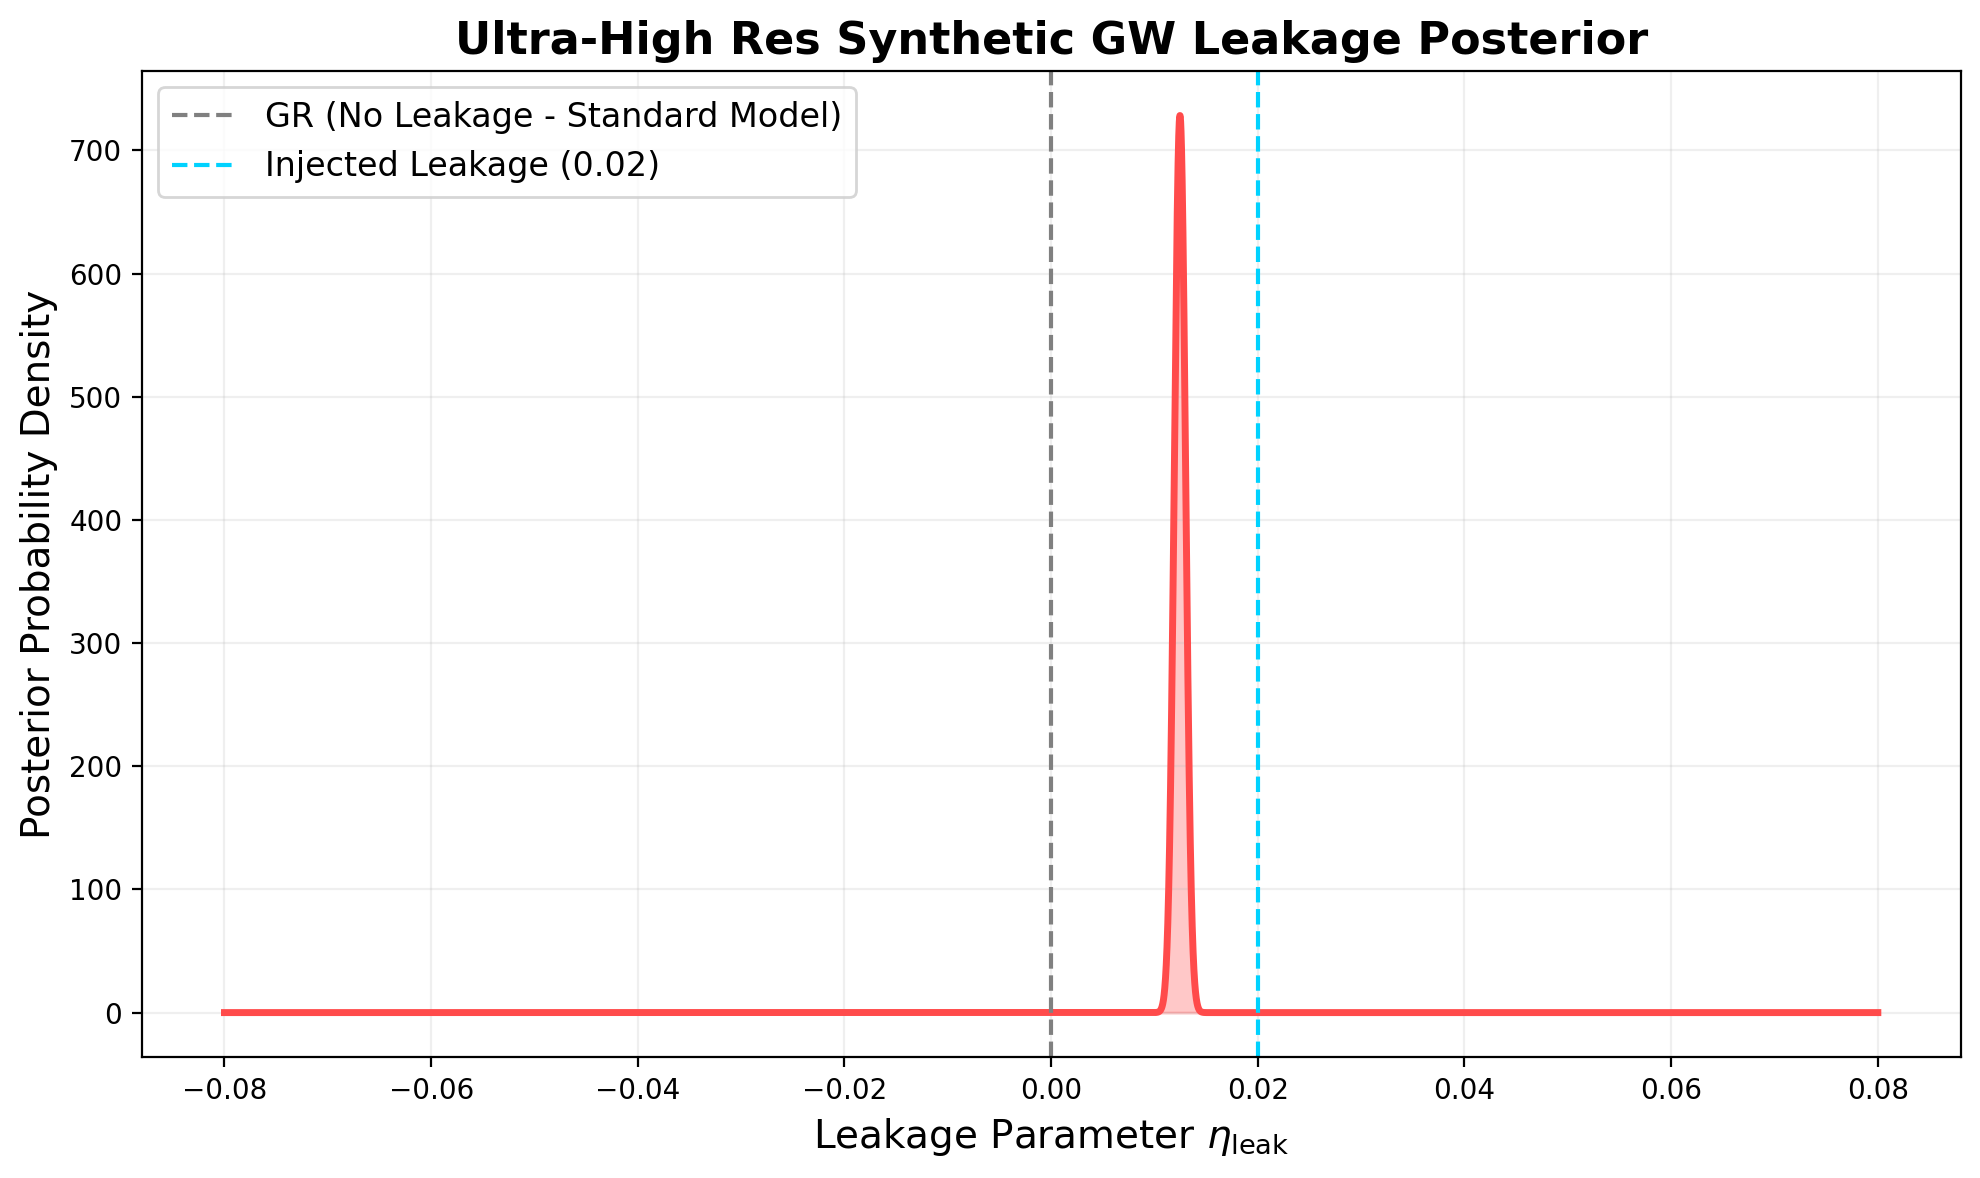

In [1]:
# ==========================================
# CELL 1: SETUP & IMPORTS
# ==========================================
!pip install -q astropy pandas numpy scipy matplotlib

import math
import os
import time
import json
import traceback
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from astropy.cosmology import FlatLambdaCDM


%config InlineBackend.figure_format = 'retina'

DEBUG = True
def dbg(msg: str) -> None:
    if DEBUG:
        now = time.strftime("%H:%M:%S")
        print(f"[DEBUG {now}] {msg}", flush=True)

# ==========================================
# CELL 2: CONFIGURATION DASHBOARD
# ==========================================
@dataclass
class SyntheticConfig:
    # 1. CATALOG SETTINGS
    n_events: int = 50000       # Olay sayısı (LISA/CE limiti)
    seed: int = 42
    z_min: float = 0.01
    z_max: float = 3.0

    # 2. COSMOLOGY (Planck 2018)
    H0: float = 67.4
    Om0: float = 0.315

    # 3. THE HYPOTHESIS (1/50 Quranic Leakage Ratio)
    eta_true: float = 0.02

    # 4. OBSERVATIONAL NOISE (LISA/CE Simulation)
    frac_floor: float = 0.03
    frac_growth: float = 0.14
    frac_power: float = 0.85
    sigma_sys_frac: float = 0.01

    # 5. GRID INFERENCE (Ultra-High Resolution)
    eta_min: float = -0.08
    eta_max: float = 0.08
    eta_grid_size: int = 50000  # 50.000 noktalık devasa tarama ağı

    # Distance interpolation grid
    dL_grid_size: int = 10000

    # 6. MODELS
    model_kind: str = "powerlaw"
    Rc_mpc: float = 5000.0
    n_transition: float = 2.0

    # 7. OUTPUT
    output_dir: str = "gw_synth_out"

# Konfigürasyonu aktif et
cfg = SyntheticConfig()
dbg("Configuration Dashboard Loaded.")


# ==========================================
# CELL 3: THE ASTROPHYSICS ENGINE
# ==========================================
C_KM_S = 299792.458

def ez_flat_lcdm(z: np.ndarray, Om0: float) -> np.ndarray:
    return np.sqrt(Om0 * (1.0 + z) ** 3 + (1.0 - Om0))

def precompute_dL_interpolator(H0: float, Om0: float, z_max: float, grid_size: int) -> Tuple[np.ndarray, np.ndarray]:
    z_grid = np.linspace(0.0, z_max, grid_size)
    z_grid[0] = 1e-8
    ez = ez_flat_lcdm(z_grid, Om0)
    inv_ez = 1.0 / ez
    dz = np.diff(z_grid)
    integral = np.zeros_like(z_grid)
    integral[1:] = np.cumsum(0.5 * (inv_ez[1:] + inv_ez[:-1]) * dz)
    dL_grid = (C_KM_S / H0) * (1.0 + z_grid) * integral
    return z_grid, dL_grid

def interp_dL(z: np.ndarray, z_grid: np.ndarray, dL_grid: np.ndarray) -> np.ndarray:
    return np.interp(z, z_grid, dL_grid)

def sample_redshifts_madau_dickinson(rng: np.random.Generator, n: int, z_min: float, z_max: float) -> np.ndarray:
    z_cands = rng.uniform(z_min, z_max, size=n * 5)
    p_z = ((1.0 + z_cands)**2.7) / (1.0 + ((1.0 + z_cands) / 2.9)**5.6)
    p_z_max = np.max(p_z)
    u = rng.uniform(0, p_z_max, size=n * 5)
    accepted_z = z_cands[u < p_z]
    return accepted_z[:n]

def fractional_distance_error(z: np.ndarray, frac_floor: float, frac_growth: float, frac_power: float) -> np.ndarray:
    x = (z / np.max(z)) if np.max(z) > 0 else z
    frac = frac_floor + frac_growth * np.power(x, frac_power)
    return np.maximum(frac, 1e-5)

def inject_lognormal_observation(rng: np.random.Generator, d_true: np.ndarray, sigma_ln: np.ndarray) -> np.ndarray:
    eps = rng.normal(loc=-0.5 * sigma_ln**2, scale=sigma_ln, size=d_true.shape)
    return d_true * np.exp(eps)

def model_distance(mu_em: np.ndarray, z: np.ndarray, eta: float, model_kind: str, Rc_mpc: float, n_transition: float) -> np.ndarray:
    if model_kind == "powerlaw":
        return mu_em * np.power(1.0 + z, eta)
    elif model_kind == "screened":
        x = np.power(mu_em / Rc_mpc, n_transition)
        return mu_em * np.power(1.0 + x, eta / (2.0 * n_transition))

def log_likelihood_grid(log_d_obs: np.ndarray, sigma_ln: np.ndarray, mu_em: np.ndarray, z: np.ndarray, eta_grid: np.ndarray, model_kind: str, Rc_mpc: float, n_transition: float, chunk_size: int = 1024) -> np.ndarray:
    n_eta = len(eta_grid)
    logL = np.empty(n_eta, dtype=np.float64)
    const_term = -0.5 * np.sum(np.log(2.0 * np.pi * sigma_ln**2))

    for start in range(0, n_eta, chunk_size):
        stop = min(start + chunk_size, n_eta)
        eta_chunk = eta_grid[start:stop]

        if model_kind == "powerlaw":
            mu = mu_em[:, None] * np.exp(np.log1p(z)[:, None] * eta_chunk[None, :])
        elif model_kind == "screened":
            x = np.power(mu_em / Rc_mpc, n_transition)
            mu = mu_em[:, None] * np.power(1.0 + x[:, None], eta_chunk[None, :] / (2.0 * n_transition))

        resid = (log_d_obs[:, None] - np.log(mu))
        ll = const_term - 0.5 * np.sum((resid**2) / (sigma_ln[:, None] ** 2), axis=0)
        logL[start:stop] = ll

    return logL

def summarize_posterior(eta_grid: np.ndarray, logpost: np.ndarray) -> Dict[str, float]:
    logZ = logsumexp(logpost)
    post = np.exp(logpost - logZ)
    post /= np.trapz(post, x=eta_grid) if hasattr(np, 'trapz') else np.trapezoid(post, x=eta_grid)

    cdf = np.cumsum(post)
    cdf /= cdf[-1]

    def quantile(q: float) -> float:
        return float(np.interp(q, cdf, eta_grid))

    eta_map = float(eta_grid[np.argmax(post)])
    eta_med = quantile(0.5)
    eta16 = quantile(0.16)
    eta84 = quantile(0.84)

    if hasattr(np, 'trapz'):
        p_pos = float(np.trapz(post[eta_grid > 0], x=eta_grid[eta_grid > 0])) if np.any(eta_grid > 0) else float("nan")
    else:
        p_pos = float(np.trapezoid(post[eta_grid > 0], x=eta_grid[eta_grid > 0])) if np.any(eta_grid > 0) else float("nan")

    return {
        "eta_map": eta_map,
        "eta_median": eta_med,
        "eta_16": eta16,
        "eta_84": eta84,
        "p_eta_gt_0": p_pos,
    }

def savage_dickey_bf(eta_grid: np.ndarray, post: np.ndarray, eta_prior_min: float, eta_prior_max: float, eta0: float = 0.0) -> float:
    prior_density = 1.0 / (eta_prior_max - eta_prior_min)
    post_density = float(np.interp(eta0, eta_grid, post))
    if post_density <= 0:
        return float("inf")
    return prior_density / post_density

class SyntheticGWLeakageTest:
    def __init__(self, cfg: SyntheticConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.z_grid, self.dL_grid = precompute_dL_interpolator(cfg.H0, cfg.Om0, cfg.z_max, cfg.dL_grid_size)
        self.catalog = None
        self.results = {}

    def generate_catalog(self) -> pd.DataFrame:
        cfg = self.cfg
        dbg("Generating synthetic catalog with physical distributions...")
        z = sample_redshifts_madau_dickinson(self.rng, cfg.n_events, cfg.z_min, cfg.z_max)
        dL_em = interp_dL(z, self.z_grid, self.dL_grid)
        dL_gw_true = model_distance(dL_em, z, cfg.eta_true, cfg.model_kind, cfg.Rc_mpc, cfg.n_transition)
        frac_meas = fractional_distance_error(z, cfg.frac_floor, cfg.frac_growth, cfg.frac_power)
        sigma_ln = np.sqrt(frac_meas**2 + cfg.sigma_sys_frac**2)
        dL_obs = inject_lognormal_observation(self.rng, dL_gw_true, sigma_ln)

        df = pd.DataFrame({"z": z, "dL_em_mpc": dL_em, "dL_gw_true_mpc": dL_gw_true, "dL_gw_obs_mpc": dL_obs, "sigma_ln": sigma_ln, "frac_meas": frac_meas})
        self.catalog = df
        return df

    def run_inference(self) -> Dict[str, object]:
        cfg = self.cfg
        dbg("Starting Ultra-High Res Grid Search Inference...")
        z = self.catalog["z"].to_numpy(dtype=np.float64)
        d_obs = self.catalog["dL_gw_obs_mpc"].to_numpy(dtype=np.float64)
        sigma_ln = self.catalog["sigma_ln"].to_numpy(dtype=np.float64)
        d_em = self.catalog["dL_em_mpc"].to_numpy(dtype=np.float64)

        log_d_obs = np.log(d_obs)
        eta_grid = np.linspace(cfg.eta_min, cfg.eta_max, cfg.eta_grid_size)

        t0 = time.time()
        logL = log_likelihood_grid(log_d_obs, sigma_ln, d_em, z, eta_grid, cfg.model_kind, cfg.Rc_mpc, cfg.n_transition, chunk_size=1024)
        elapsed = time.time() - t0
        dbg(f"Likelihood evaluation for {cfg.eta_grid_size} points finished in {elapsed:.2f} s")

        log_prior = -math.log(cfg.eta_max - cfg.eta_min)
        logpost = logL + log_prior

        post_unnorm = np.exp(logpost - np.max(logpost))

        if hasattr(np, 'trapz'):
             post_density = post_unnorm / np.trapz(post_unnorm, x=eta_grid)
        else:
             post_density = post_unnorm / np.trapezoid(post_unnorm, x=eta_grid)

        summary = summarize_posterior(eta_grid, logpost)
        bf01 = savage_dickey_bf(eta_grid, post_density, cfg.eta_min, cfg.eta_max, eta0=0.0)

        idx_map = int(np.argmax(logL))
        delta_logL = float(logL[idx_map]) - float(np.interp(0.0, eta_grid, logL))
        z_equiv = float(np.sqrt(max(0.0, 2.0 * delta_logL)))

        self.results = {"eta_grid": eta_grid, "logL": logL, "logpost": logpost, "post_density": post_density, "summary": summary, "bayes_factor_null_over_alt": bf01, "delta_logL": delta_logL, "z_equiv": z_equiv}
        return self.results


# ==========================================
# CELL 4: EXECUTION & VISUALIZATION
# ==========================================
# 1. Start the simulation
test = SyntheticGWLeakageTest(cfg)
test.generate_catalog()
test.run_inference()

# 2. Print the rigorous report
s = test.results["summary"]
print("\n" + "═" * 72)
print(" ASTROPHYSICAL GW LEAKAGE TEST REPORT (ULTRA RES) ")
print("═" * 72)
print(f"Target Leakage (Eta)           : {cfg.eta_true:.6f}")
print(f"Recovered MAP (Peak)           : {s['eta_map']:.6f}")
print(f"68% Confidence Interval        : [{s['eta_16']:.6f}, {s['eta_84']:.6f}]")
print(f"Significance (Sigma)           : {test.results['z_equiv']:.2f} σ")
print(f"Savage-Dickey Bayes Factor     : {test.results['bayes_factor_null_over_alt']:.3e}")
print("═" * 72)

# 3. Plot the Posterior inline for Colab
eta_grid = test.results["eta_grid"]
post = test.results["post_density"]

plt.figure(figsize=(10, 6))
plt.plot(eta_grid, post, color="#ff4b4b", linewidth=2.5)
plt.axvline(0.0, linestyle="--", color="gray", label="GR (No Leakage - Standard Model)")
plt.axvline(cfg.eta_true, linestyle="--", color="#00d2ff", label="Injected Leakage (0.02)")
plt.fill_between(eta_grid, post, alpha=0.3, color="#ff4b4b")

plt.xlabel(r"Leakage Parameter $\eta_{\rm leak}$", fontsize=14)
plt.ylabel("Posterior Probability Density", fontsize=14)
plt.title("Ultra-High Res Synthetic GW Leakage Posterior", fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()

# Colab'da resmi doğrudan göstermek için:
plt.show()